In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/crop-pest-and-disease-detection-dataset/val/val/Tomato verticulium wilt/verticulium wilt578_.jpg
/kaggle/input/crop-pest-and-disease-detection-dataset/val/val/Tomato verticulium wilt/verticulium wilt454_.jpg
/kaggle/input/crop-pest-and-disease-detection-dataset/val/val/Tomato verticulium wilt/verticulium wilt287_.jpg
/kaggle/input/crop-pest-and-disease-detection-dataset/val/val/Tomato verticulium wilt/verticulium wilt83_.jpg
/kaggle/input/crop-pest-and-disease-detection-dataset/val/val/Tomato verticulium wilt/verticulium wilt145_.jpg
/kaggle/input/crop-pest-and-disease-detection-dataset/val/val/Tomato verticulium wilt/verticulium wilt480_.jpg
/kaggle/input/crop-pest-and-disease-detection-dataset/val/val/Tomato verticulium wilt/verticulium wilt596_.jpg
/kaggle/input/crop-pest-and-disease-detection-dataset/val/val/Tomato verticulium wilt/verticulium wilt362_.jpg
/kaggle/input/crop-pest-and-disease-detection-dataset/val/val/Tomato verticulium wilt/verticulium wilt165_.jpg
/k

#### Import necessary libraries.

In [4]:
import os
import shutil
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from PIL import Image, UnidentifiedImageError
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

2025-07-08 21:19:08.821553: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752009549.226542      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752009549.337457      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


#### Observed some corrupt or unreadable images in the dataset. These entire dataset was coopied to a writable directory and the corrupt images were dropped.

In [5]:
# ORIGINAL DIRECTORIES (READ-ONLY)
BASE_INPUT = "/kaggle/input/crop-pest-and-disease-detection-dataset"
train_src = os.path.join(BASE_INPUT, "train/train")
val_src   = os.path.join(BASE_INPUT, "val/val")
test_src  = os.path.join(BASE_INPUT, "test/test")

# TARGET CLEAN DIRECTORIES (WRITABLE)
BASE_OUTPUT = "/kaggle/working"
train_dst = os.path.join(BASE_OUTPUT, "train_cleaned")
val_dst   = os.path.join(BASE_OUTPUT, "val_cleaned")
test_dst  = os.path.join(BASE_OUTPUT, "test_cleaned")

# COPY FUNCTION
def copy_if_not_exists(src, dst):
    if not os.path.exists(dst):
        shutil.copytree(src, dst)
        print(f"Copied: {src} → {dst}")
    else:
        print(f"Already exists: {dst}")

# Copy each dataset
copy_if_not_exists(train_src, train_dst)
copy_if_not_exists(val_src, val_dst)
copy_if_not_exists(test_src, test_dst)

# CORRUPT IMAGE REMOVAL FUNCTION

def delete_fully_corrupt_images(directory):
    deleted_files = []
    for root, _, files in os.walk(directory):
        for file in files:
            path = os.path.join(root, file)
            try:
                with Image.open(path) as img:
                    img = img.convert("RGB")        # Decode
                    img = img.resize((128, 128))    # Force resize to ensure it's usable
                    img.load()                      # Force full load
            except (UnidentifiedImageError, OSError, ValueError) as e:
                print(f"Deleting corrupt: {path} — {e}")
                try:
                    os.remove(path)
                    deleted_files.append(path)
                except Exception as delete_err:
                    print(f"Could not delete {path}: {delete_err}")
    print(f"\nDone. Deleted {len(deleted_files)} corrupt images.")

# Clean all three datasets
delete_fully_corrupt_images(train_dst)
delete_fully_corrupt_images(val_dst)
delete_fully_corrupt_images(test_dst)

Copied: /kaggle/input/crop-pest-and-disease-detection-dataset/train/train → /kaggle/working/train_cleaned
Copied: /kaggle/input/crop-pest-and-disease-detection-dataset/val/val → /kaggle/working/val_cleaned
Copied: /kaggle/input/crop-pest-and-disease-detection-dataset/test/test → /kaggle/working/test_cleaned
Deleting corrupt: /kaggle/working/train_cleaned/Maize leaf beetle/leaf beetle690_.jpg — cannot identify image file '/kaggle/working/train_cleaned/Maize leaf beetle/leaf beetle690_.jpg'
Deleting corrupt: /kaggle/working/train_cleaned/Maize leaf beetle/leaf beetle457_.jpg — broken data stream when reading image file
Deleting corrupt: /kaggle/working/train_cleaned/Maize leaf beetle/leaf beetle572_.jpg — broken data stream when reading image file
Deleting corrupt: /kaggle/working/train_cleaned/Maize leaf beetle/leaf beetle208_.jpg — Truncated File Read
Deleting corrupt: /kaggle/working/train_cleaned/Maize leaf beetle/leaf beetle798_.jpg — cannot identify image file '/kaggle/working/trai

#### Define data paths.

In [6]:
train_dir = '/kaggle/working/train_cleaned'
val_dir = '/kaggle/working/val_cleaned'
test_dir = '/kaggle/working/test_cleaned'

#### Define image height, batch size and number of epochs.

In [7]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
EPOCHS = 50

#### Data Preprocessing.

In [8]:
# Augmentation for Training Data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=65,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Only rescale for validation and test sets
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [9]:
# Generators for train, test and validation.
train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_mode='categorical',
    seed = 42
)

val_generator = val_test_datagen.flow_from_directory(
    directory=val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_mode='categorical',
    seed = 42
)

test_generator = val_test_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_mode='categorical',
    shuffle=False,
    seed = 42

)

Found 17570 images belonging to 22 classes.
Found 2504 images belonging to 22 classes.
Found 5052 images belonging to 22 classes.


#### Get Class Information

In [10]:
num_classes = len(train_generator.class_indices)
print("Classes:", train_generator.class_indices)

Classes: {'Cashew anthracnose': 0, 'Cashew gumosis': 1, 'Cashew healthy': 2, 'Cashew leaf miner': 3, 'Cashew red rust': 4, 'Cassava bacterial blight': 5, 'Cassava brown spot': 6, 'Cassava green mite': 7, 'Cassava healthy': 8, 'Cassava mosaic': 9, 'Maize fall armyworm': 10, 'Maize grasshoper': 11, 'Maize healthy': 12, 'Maize leaf beetle': 13, 'Maize leaf blight': 14, 'Maize leaf spot': 15, 'Maize streak virus': 16, 'Tomato healthy': 17, 'Tomato leaf blight': 18, 'Tomato leaf curl': 19, 'Tomato septoria leaf spot': 20, 'Tomato verticulium wilt': 21}


#### Build and compile the model.

In [11]:
# Model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1752009809.620775      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1752009809.621550      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 22)             │         2,838 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,307,478 (12.62 MB)

 Trainable params: 3,307,478 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

#### Implement callbacks (checkpoint and early stopping).

In [13]:
checkpoint_cb = ModelCheckpoint(
    "best_model.h5", save_best_only=True, monitor="val_loss", mode="min", verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)

#### Train the model.

In [14]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, earlystop_cb]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1752009814.248491     127 service.cc:148] XLA service 0x7a7834004bf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752009814.250098     127 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1752009814.250130     127 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1752009814.630372     127 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/550 ━━━━━━━━━━━━━━━━━━━━ 44s 82ms/step - accuracy: 0.1007 - loss: 3.2135  

I0000 00:00:1752009818.583164     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.1634 - loss: 2.8354
Epoch 1: val_loss improved from inf to 2.31892, saving model to best_model.h5
550/550 ━━━━━━━━━━━━━━━━━━━━ 95s 161ms/step - accuracy: 0.1635 - loss: 2.8352 - val_accuracy: 0.2955 - val_loss: 2.3189
Epoch 2/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.2548 - loss: 2.3992
Epoch 2: val_loss improved from 2.31892 to 1.95936, saving model to best_model.h5
550/550 ━━━━━━━━━━━━━━━━━━━━ 86s 156ms/step - accuracy: 0.2548 - loss: 2.3991 - val_accuracy: 0.3702 - val_loss: 1.9594
Epoch 3/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.3113 - loss: 2.1884
Epoch 3: val_loss improved from 1.95936 to 1.78556, saving model to best_model.h5
550/550 ━━━━━━━━━━━━━━━━━━━━ 87s 158ms/step - accuracy: 0.3113 - loss: 2.1884 - val_accuracy: 0.4345 - val_loss: 1.7856
Epoch 4/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.3566 - loss: 2.0049
Epoch 4: val_loss improved from 1.78556 to 1.59392, savin

#### Plot training and validation accuracy and loss.

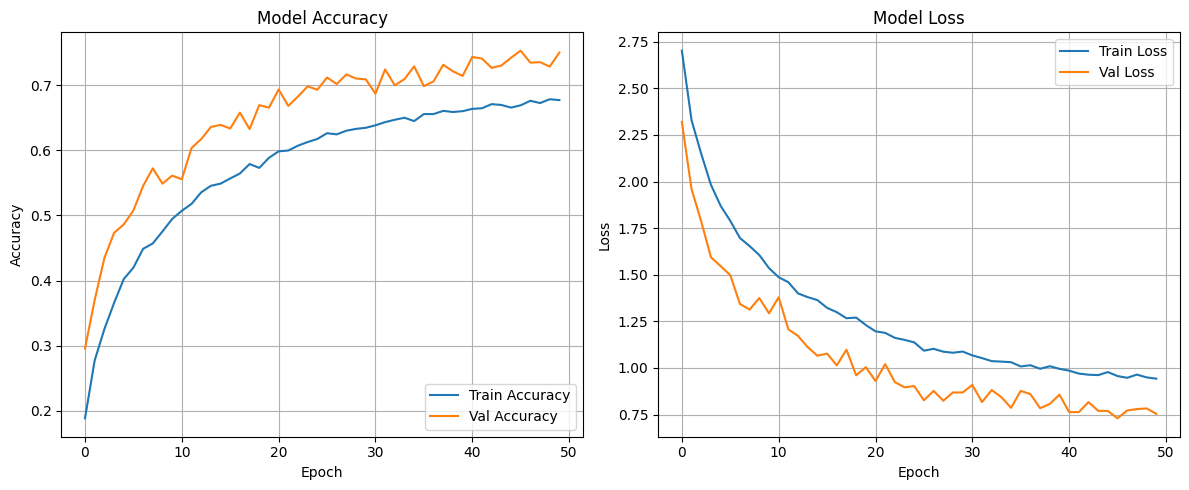

In [15]:
# Plot accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


#### Evaluate the model.

In [16]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.2f}")

158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.7961 - loss: 0.6332
Test Accuracy: 0.73


#### Plot testing accuracy and loss

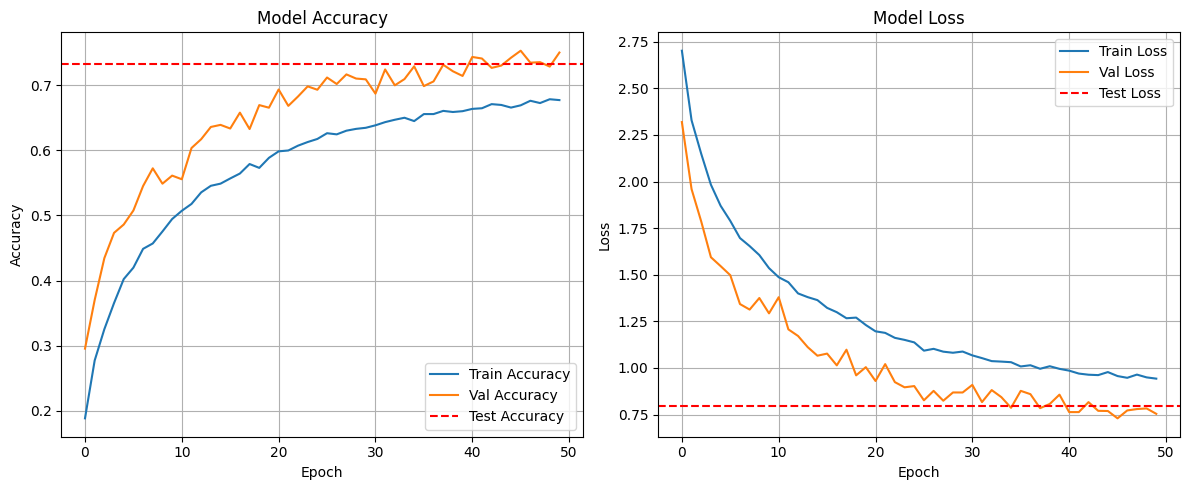

In [17]:
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.axhline(y=test_acc, color='r', linestyle='--', label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.axhline(y=test_loss, color='r', linestyle='--', label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

#### Load the classification report.

In [19]:
from sklearn.metrics import classification_report
import numpy as np

# Get ground truth and predictions
y_true = test_generator.classes  # True labels
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert probabilities to class indices

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Classification report
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

158/158 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step
                           precision    recall  f1-score   support

       Cashew anthracnose       0.73      0.78      0.75       347
           Cashew gumosis       0.87      0.99      0.92        79
           Cashew healthy       0.83      0.80      0.81       275
        Cashew leaf miner       0.77      0.86      0.81       277
          Cashew red rust       0.97      0.96      0.96       337
 Cassava bacterial blight       0.64      0.77      0.70       524
       Cassava brown spot       0.79      0.75      0.77       297
       Cassava green mite       0.80      0.65      0.72       204
          Cassava healthy       0.79      0.89      0.84       239
           Cassava mosaic       0.89      0.80      0.84       242
      Maize fall armyworm       0.63      0.45      0.53        58
         Maize grasshoper       0.86      0.76      0.80       135
            Maize healthy       0.58      0.26      0.36        42
        Maize leaf 